In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans

In [2]:
image_path=('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes/Y1.jpg')
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print({image.shape})
print(f"pixel values ranges from {image.min()} to {image.max()}")

{(218, 180)}
pixel values ranges from 0 to 255


In [3]:
image_normalized= image/255.0
image_processed=cv2.GaussianBlur(image_normalized, (15,15), 0) #blurring to reduce noise

In [4]:
height, width = image_processed.shape
pixels = image_processed.reshape(-1, 1)
print(f"reshaped {height}x{width} image into {len(pixels)} pixels")

#2d to 1d cause kmeans only deal with nums

reshaped 218x180 image into 39240 pixels


In [5]:
k=4 #background, tissue, tumor
kmeans= KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels= kmeans.fit_predict(pixels) #assigning each pixel to a cluster

In [6]:
#reshape back to 2d
segmented = cluster_labels.reshape(height,width)
cluster_centers=kmeans.cluster_centers_.flatten()
print(f"cluster brightness values{cluster_centers}")

cluster brightness values[0.24778768 0.82668037 0.03711768 0.48025976]


In [7]:
#finding the tumor!
tumor_cluster_id=np.argmax(cluster_centers) #brightest cluster = likely tumor
#create mask where tumor cluster = 1 everything else=0
print(f"tumor cluster id {tumor_cluster_id}")
tumor_mask= (segmented == tumor_cluster_id)

tumor cluster id 1


Text(0.5, 1.0, 'tumor highlighted cluster with high intense')

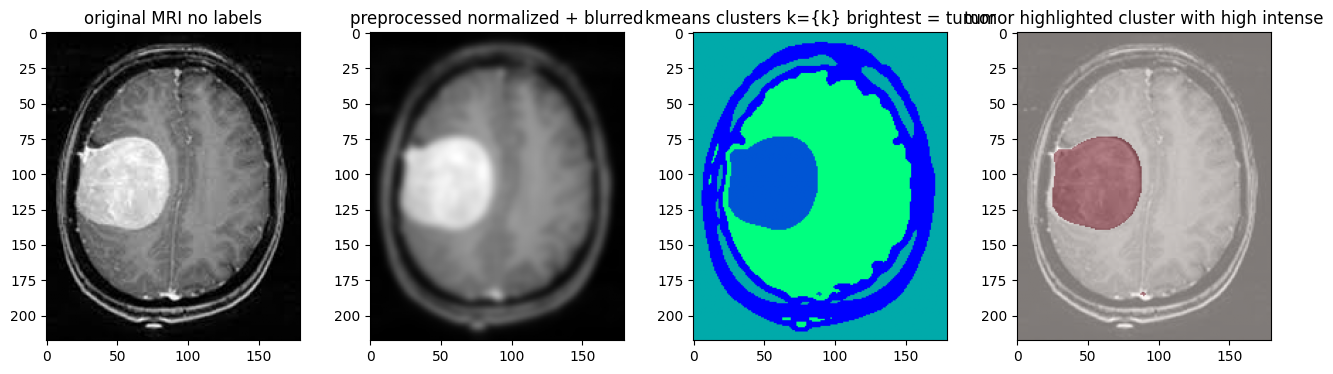

In [8]:
#visuals 
fig, axes = plt.subplots(1, 4, figsize=(16,4))
#original img
axes[0].imshow(image, cmap='gray')
axes[0].set_title("original MRI no labels")

#preprocessed img 
axes[1].imshow(image_processed, cmap='gray')
axes[1].set_title('preprocessed normalized + blurred')

#segmented img 
axes[2].imshow(segmented, cmap='winter')
axes[2].set_title("kmeans clusters k={k} brightest = tumor")

#tumor overlay
axes[3].imshow(image, cmap='gray')
axes[3].imshow(tumor_mask, cmap='Reds', alpha=0.5) # red = tumor
axes[3].set_title('tumor highlighted cluster with high intense')

In [9]:
#tumor area percentage calculation 
tumor_pct = (tumor_mask.sum() / tumor_mask.size) * 100
plt.suptitle(f"Brain MRI Segmentation | Estimated Tumor Area: {tumor_pct:.2f}%", fontsize=14)
plt.tight_layout()
print(f"tumor area {tumor_pct:.2f}%")

tumor area 8.79%


<Figure size 640x480 with 0 Axes>